In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Dataset Downloaded to " , dataset_path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset Downloaded to  /kaggle/input/pima-indians-diabetes-database


In [ ]:
import os
import pandas as pd

csv_file = os.path.join(dataset_path , "diabetes.csv")
df = pd.read_csv(csv_file)

print(df.shape)
print(df.head())


(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
X = df.drop("Outcome" , axis = 1)
y = df["Outcome"]

print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state = 42)
model.fit(X_train , y_train)

train_acc = model.score(X_train , y_train)
test_acc = model.score(X_test , y_test)

print("Train Accuracy : " , train_acc)
print("Test Accuracy : " , test_acc)

Train Accuracy :  1.0
Test Accuracy :  0.7337662337662337


In [ ]:
import lime
from lime import lime_tabular


explainer = lime_tabular.LimeTabularExplainer(X_train, feature_names=X.columns.tolist(), class_names=("No Diabetes", "Diabetes"), mode="classification")

In [ ]:
instance_idx = 0
instance = X_test[instance_idx]

exp = explainer.explain_instance(
    data_row = instance,
    predict_fn = model.predict_proba,
    num_features = 10
)

In [ ]:
print("Explanation for test instance ", instance_idx)

for feature , weight in exp.as_list():
  print(f"{feature}:{weight:.4f}")

Explanation for test instance  0
Glucose <= -0.65:-0.2074
Age > 0.62:0.1449
0.00 < BMI <= 0.57:0.0699
Insulin > 0.42:0.0613
SkinThickness > 0.75:0.0252
BloodPressure <= -0.29:0.0156
-0.29 < DiabetesPedigreeFunction <= 0.43:0.0107
-0.22 < Pregnancies <= 0.68:-0.0073


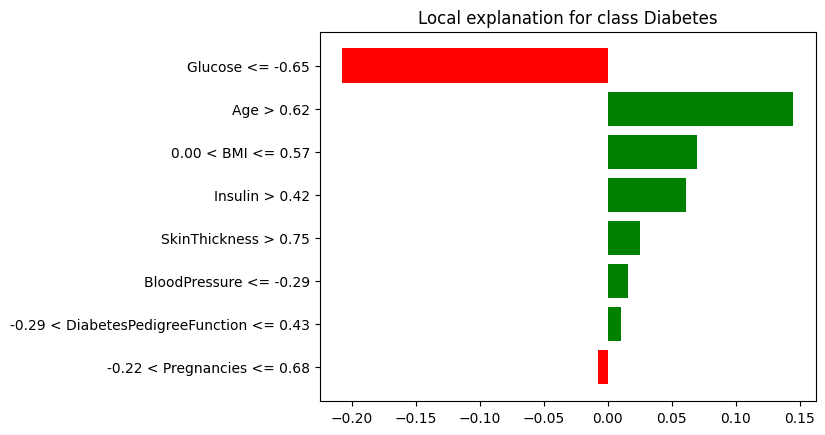

In [ ]:
import matplotlib.pyplot as plt
fig = exp.as_pyplot_figure()
plt.show()

Actual : 0 , Predicted : 0
Actual : 0 , Predicted : 0
Actual : 0 , Predicted : 0


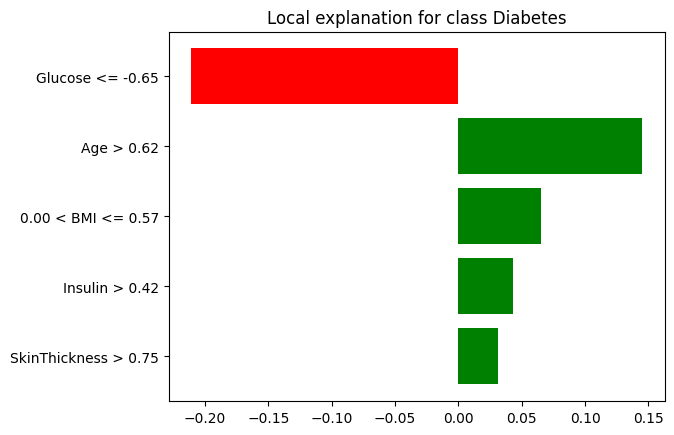

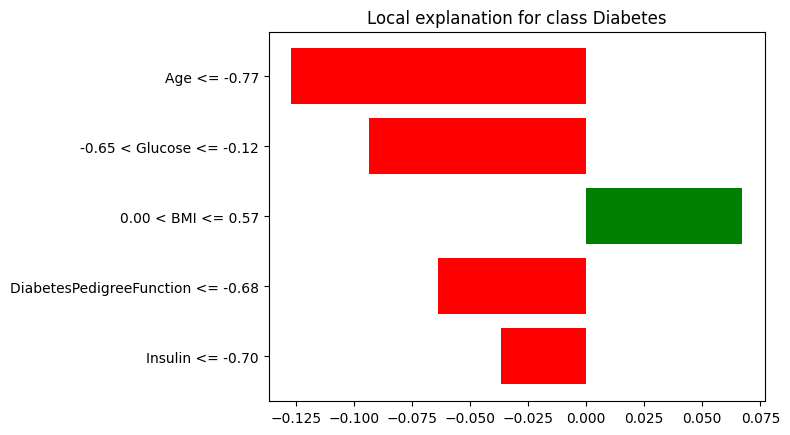

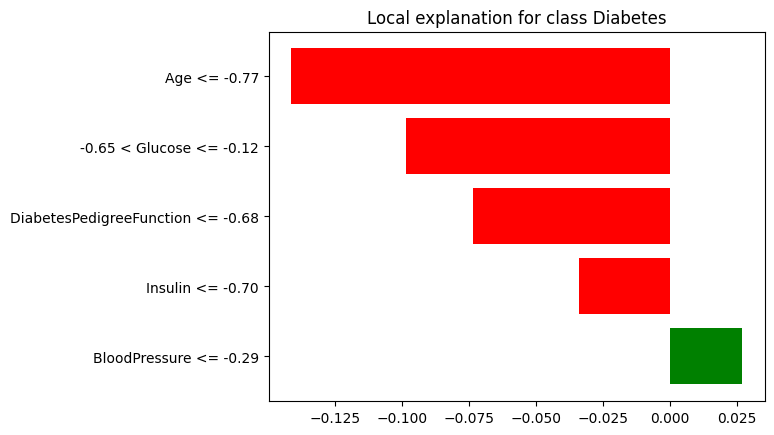

In [ ]:
for i in range(3):
  exp_i = explainer.explain_instance(
      data_row = X_test[i],
      predict_fn = model.predict_proba,
      num_features = 5
  )
  actual = y_test.iloc[i]
  predicted = model.predict(X_test[i].reshape(1,-1))[0]
  print(f"Actual : {actual} , Predicted : {predicted}")
  fig = exp_i.as_pyplot_figure()